# Workflow Orchestration Benchmarks Analysis

This notebook analyzes and visualizes the performance benchmarks for different workflow orchestrators.

## Import Required Libraries

We'll import pandas for data manipulation, matplotlib and seaborn for visualization, and re for parsing markdown data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Load and Parse the Markdown Data

Read the markdown file, extract the benchmark table, and convert it into a pandas DataFrame.

In [3]:
# Read the markdown file
md_path = Path('workflow-benchmarks.md')
with open(md_path, 'r') as f:
    content = f.read()

# Extract data from markdown table
data = []
lines = content.split('\n')

for line in lines:
    # Look for table rows (lines with pipe separators)
    if line.strip().startswith('|') and not line.strip().startswith('|---') and '**Celery**' in line or '**Temporal**' in line or ('Temporal' in line and 'v1' in line):
        # Split by pipe and clean
        cells = [cell.strip() for cell in line.split('|')[1:-1]]
        
        if len(cells) == 6:
            # Extract values
            orchestrator = cells[0].replace('**', '')
            version = cells[1].replace('**', '')
            replicas = cells[2] if cells[2] != '—' else 'N/A'
            concurrency = cells[3] if cells[3] != '—' else 'N/A'
            workers = cells[4] if cells[4] != '—' else 'N/A'
            time_str = cells[5].replace('**', '').replace('⚡', '').strip()
            
            # Convert time to seconds
            time_parts = re.match(r'(\d+)m(\d+)s', time_str)
            if time_parts:
                seconds = int(time_parts.group(1)) * 60 + int(time_parts.group(2))
            else:
                continue
            
            data.append({
                'Orchestrator': orchestrator,
                'Version': version,
                'Replicas': replicas,
                'Concurrency': concurrency,
                'Workers': workers,
                'Time (seconds)': seconds,
                'Time (formatted)': time_str
            })

# Create DataFrame
df = pd.DataFrame(data)
print("Benchmark Data:")
print(df)
print(f"\nTotal benchmarks: {len(df)}")


Benchmark Data:
  Orchestrator        Version Replicas Concurrency Workers  Time (seconds)  \
0       Celery         v1.4.0      N/A         N/A     N/A             387   
1     Temporal  v1.4.1.dev228       12         N/A       1            3182   
2     Temporal  v1.4.1.dev263       12           3       1            1405   
3     Temporal  v1.4.1.dev263       12          10       1            1462   
4     Temporal  v1.4.1.dev269       12         N/A       1             849   
5     Temporal  v1.4.1.dev269        1         N/A      12             822   

  Time (formatted)  
0            6m27s  
1            53m2s  
2           23m25s  
3           24m22s  
4           14m09s  
5           13m42s  

Total benchmarks: 6


## Create a Comparison Plot

Generate visualizations comparing processing times across different orchestrators and configurations.

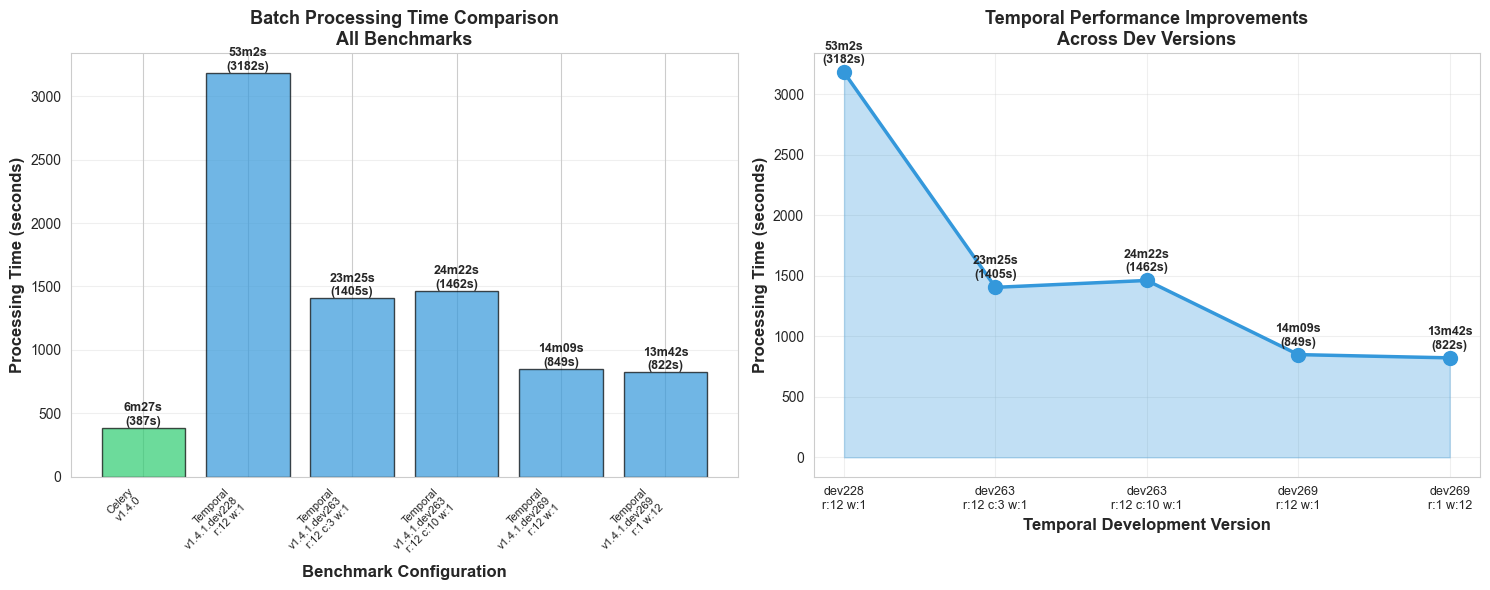


✓ Plots created successfully!
✓ Plot saved to benchmark_comparison.png

Label abbreviations: r=Replicas, c=Concurrency, w=Workers


In [6]:
# Create a comparison plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: All benchmarks comparison
ax1 = axes[0]
colors = ['#2ecc71' if x == 'Celery' else '#3498db' for x in df['Orchestrator']]
bars1 = ax1.bar(range(len(df)), df['Time (seconds)'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Benchmark Configuration', fontsize=12, fontweight='bold')
ax1.set_ylabel('Processing Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Batch Processing Time Comparison\nAll Benchmarks', fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(df)))

# Create detailed labels with configuration info
detailed_labels = []
for _, row in df.iterrows():
    label = f"{row['Orchestrator']}\n{row['Version']}"
    config_parts = []
    if row['Replicas'] != 'N/A':
        config_parts.append(f"r:{row['Replicas']}")
    if row['Concurrency'] != 'N/A':
        config_parts.append(f"c:{row['Concurrency']}")
    if row['Workers'] != 'N/A':
        config_parts.append(f"w:{row['Workers']}")
    
    if config_parts:
        label += "\n" + " ".join(config_parts)
    
    detailed_labels.append(label)

ax1.set_xticklabels(detailed_labels, rotation=45, ha='right', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, row) in enumerate(zip(bars1, df.itertuples())):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f"{row._7}\n({int(height)}s)",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Temporal version progression
temporal_df = df[df['Orchestrator'] == 'Temporal'].copy()
temporal_df['Version_short'] = temporal_df['Version'].str.replace('v1.4.1.dev', 'dev')

ax2 = axes[1]
ax2.plot(range(len(temporal_df)), temporal_df['Time (seconds)'], 
         marker='o', linewidth=2.5, markersize=10, color='#3498db', label='Processing Time')
ax2.fill_between(range(len(temporal_df)), temporal_df['Time (seconds)'], alpha=0.3, color='#3498db')
ax2.set_xlabel('Temporal Development Version', fontsize=12, fontweight='bold')
ax2.set_ylabel('Processing Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Temporal Performance Improvements\nAcross Dev Versions', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(temporal_df)))

# Create labels with configuration for temporal versions
temporal_labels = []
for _, row in temporal_df.iterrows():
    label = row['Version_short']
    config_parts = []
    if row['Replicas'] != 'N/A':
        config_parts.append(f"r:{row['Replicas']}")
    if row['Concurrency'] != 'N/A':
        config_parts.append(f"c:{row['Concurrency']}")
    if row['Workers'] != 'N/A':
        config_parts.append(f"w:{row['Workers']}")
    
    if config_parts:
        label += "\n" + " ".join(config_parts)
    
    temporal_labels.append(label)

ax2.set_xticklabels(temporal_labels, fontsize=9)
ax2.grid(True, alpha=0.3)

# Add value labels
for i, (x, y, row) in enumerate(zip(range(len(temporal_df)), temporal_df['Time (seconds)'], temporal_df.itertuples())):
    ax2.text(x, y + 50, f"{row._7}\n({int(y)}s)", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()

# Save figure to file
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Plots created successfully!")
print("✓ Plot saved to benchmark_comparison.png")
print("\nLabel abbreviations: r=Replicas, c=Concurrency, w=Workers")

## Key Performance Insights

### Performance Summary
- **Fastest Configuration**: Celery v1.4.0 achieves **6m27s** (387 seconds)
- **Temporal Progress**: v1.4.1.dev269 reduced time from 53m2s to 14m09s (~73% improvement)
- **Latest Optimization**: Using 1 replica with 12 workers achieves nearly identical performance (13m42s)

### Observations
1. **Celery** significantly outperforms Temporal in all configurations
2. **Temporal development versions** show continuous improvement
3. **Concurrency setting** (3 vs 10) has minimal impact on total processing time
4. **Horizontal scaling** (12 replicas × 1 worker vs 1 replica × 12 workers) shows similar results